In [2]:
import scipy
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.integrate import odeint
import numpy as np

In [3]:
# a) Define variables used in V:
phi = var(r'φ') # scalar field
k = 1
V0 = var(r'V_0')
alp = var(r'α')
M = var('M')
N = var('N')
Q = var('Q') # coupling variable
alp = 4

In [4]:
# Expression for Vs
def V(M,phi):
    return (M^(4+alp))/phi^alp

def dVdphi(M,phi):
    return -alp*V(M,phi)/phi

def dV2dphi2(M,phi):
    return alp*(alp+1)*V(M,phi)/(phi^2)

In [12]:
# Constants
h = 0.7
ohm_m = 0.31
Ho = 2.1332e-42*h*4.10677e-19 # Hubble constant in reduced plank mass units
rho_c0 = (3*Ho^2/(k^2)) # current critical energy density
show(rho_c0)
M_val = (rho_c0*(8*pi)^(alp/2))^(1/(alp+4))*.5
show(M_val)
#show(V(M_val,1))
gam = 1
Q_val = -0.01
Q = Q_val
Ni = 0
#2.82046850896656e-121 *np.pi*np.pi/2.48

1.12818740358662e-120

(8.53670269968595e-16)*pi^(1/4)

In [13]:
def CoupledSteinhardt(X,N): # Q in function would allow us to simulate coupled and uncoupled in same code
    a = exp(N) # N = ln(a)
    ai = exp(Ni)
    rho_m = rho_c0*ohm_m*(a*ai)^(-3)
    Vfunc = V(M_val,X[0])
    #Vfunc = V.subs(V0 == V_value,phi ==X[0])
    dVfunc = dVdphi(M_val,X[0])
    dV2func = dV2dphi2(M_val,X[0])

    H2 = (rho_m + Vfunc)/(3-0.5*(X[1])^2)
    HdotH2 = -0.5*((X[1])^2+ gam*rho_m/H2)
    x1prime = X[1]
    x2prime = -(3+HdotH2)*X[1] - dVfunc/H2- Q*rho_m/H2
    #show(x2prime)
    return [x1prime,x2prime]

In [14]:
def other_parameters(fi,dfi,N):
    a = exp(N) # N = ln(a)
    ai = exp(Ni)
    z = exp(-N)-1
    rho_m = rho_c0*ohm_m*(a*ai)^(-3) #1e7 is that initial pmi value
    Pot = V(M_val,fi)
    dPot = dVdphi(M_val,fi)
    H2 = (rho_m + Pot)/(3-1/2*dfi^2)
    rho_φ = 0.5*(dfi^2*H2) + Pot #Energy density of φ (ρ_φ)
    #ratio_rho = rho_φ/rho_m
    
    Track = (dV2dphi2(M_val,fi)*Pot)/(dPot)^2
    O_φ = ((k^2)/3)*(rho_φ/H2) # Ωφ
    O_m = 1-O_φ
    #ratio_O = O_φ/O_m
    
    Pφ = 0.5*(dfi^2*H2) - Pot
    Y_φ = (Pφ+rho_φ)/rho_φ
    w = Pφ/rho_φ #Equation of State wΦ
    return z,rho_φ,Pφ,O_φ,O_m,w,Y_φ,rho_m,Track

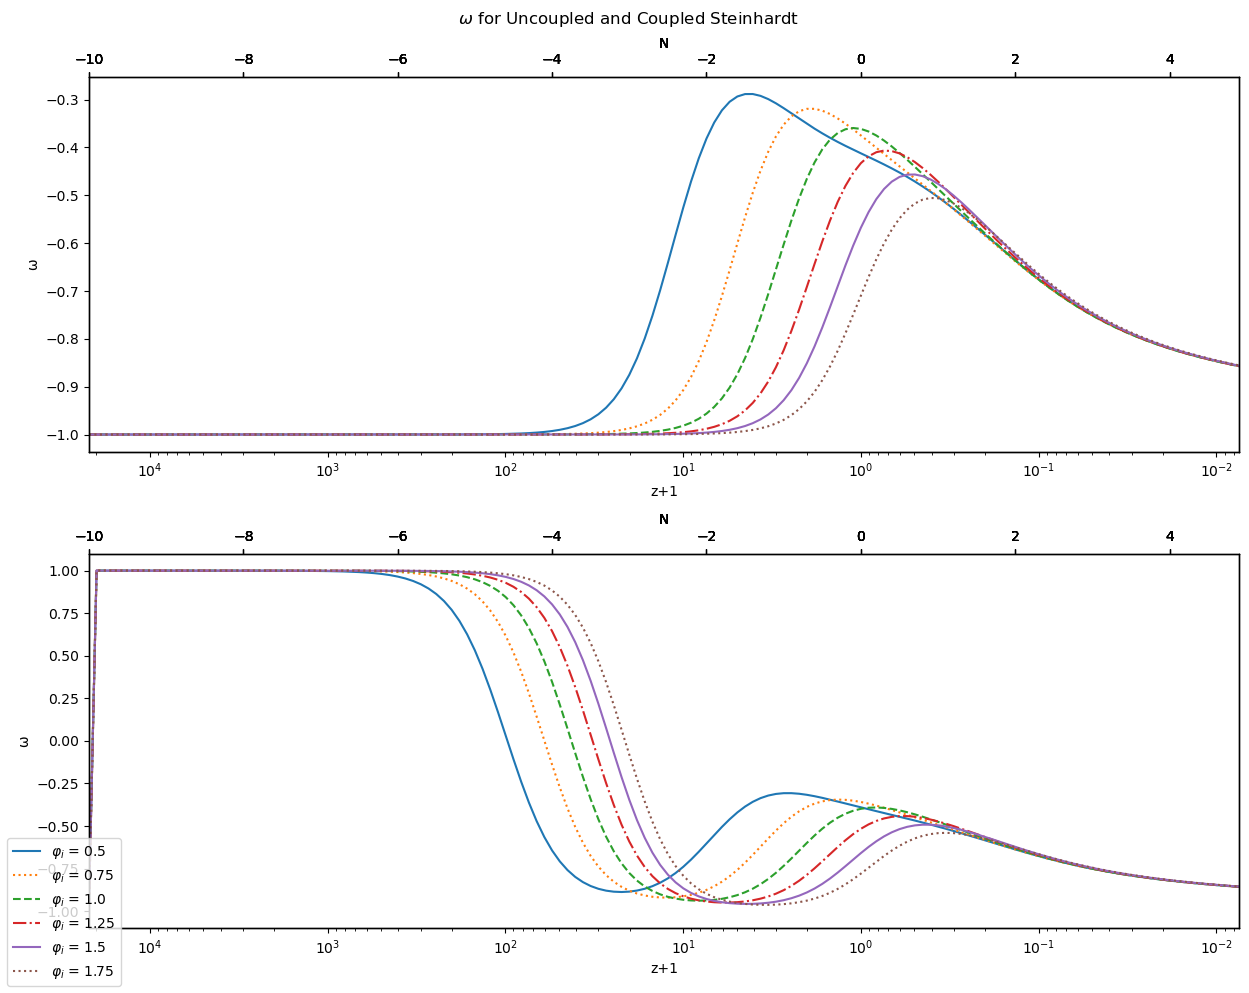

In [17]:
from itertools import cycle
StyleList = ['solid','dotted','dashed','dashdot']
lines = cycle(StyleList)
Nrange = np.arange(-10,5,.1)
Q_list = []
z_values = exp(-Nrange) # z+1

Ni = 0
fig, axs = plt.subplots(2,1, figsize=(12.5, 10),sharex=False)

# def Z2N(x):
#     return -np.log(x)

# def N2Z(x):
#     return exp(-x)


def uncoupled_vs_coupled(x,label,i,param,ls):
    fig.suptitle("${}$ for Uncoupled and Coupled Steinhardt".format(param))
    match param:
        case "φ":
            axs[0].plot(x,solQ[:,0],label=r"$φ_i$ = {}".format(i),linestyle = "{}".format(ls))
            axs[0].set(ylabel = r"$φ$", xlabel = "{}".format(label))
            axs[0].set_xlim(x[0],x[-1])
            #axs[0].set_title(r"$φ$ vs {}".format(label),loc = 'center')
            axs[1].plot(x,solCQ[:,0],label=r"$φ_i$ = {}".format(i),linestyle = "{}".format(ls))
            axs[1].set(ylabel = r"$φ$", xlabel = "{}".format(label))
            axs[1].set_xlim(x[0],x[-1])
            #axs[1].set_title(r"$φ$ vs {}".format(label),loc = 'right')

        case "φ'":
            axs[0].plot(x,solQ[:,1],label=r"$φ_i$= {}".format(i),linestyle = "{}".format(ls))
            axs[0].set(ylabel = r"$φ$'", xlabel = "{}".format(label))
            axs[0].set_xlim(x[0],x[-1])
            #axs[0].set_title(r"$φ$' vs {}".format(label),loc = 'right')
            axs[1].plot(x,solCQ[:,1],label=r"$φ_i$= {}".format(i),linestyle = "{}".format(ls))
            axs[1].set(ylabel = r"$φ$'", xlabel = "{}".format(label))
            axs[1].set_xlim(x[0],x[-1])
            #axs[1].set_title(r"$φ$' vs {}".format(label),loc = 'right')

        case "rhos":
            axs[0].plot(x,log(rho),label=r"rho")
            axs[0].plot(x,log(rho_m),label=r"rho_m")
            axs[0].set(ylabel = r"log($ρ$)", xlabel = "{}".format(label))
            axs[0].set_xlim(x[0],x[-1])
            axs[0].set_title(r"$ρ_φ$ and $ρ_m$ vs {}".format(label),loc = 'center')
            axs[1].plot(x,log(Crho),label=r"rho")
            axs[1].plot(x,log(Crho_m),label=r"rho_m")
            axs[1].set(ylabel = r"log($ρ$)", xlabel = "{}".format(label))
            axs[1].set_title(r"$ρ_φ$ and $ρ_m$ vs {}".format(label),loc = 'center')
            axs[1].set_xlim(x[0],x[-1])
            fig.suptitle("$ρ_φ$ and $ρ_m$ for Uncoupled and Coupled Steinhardt")

        case "Ω_φ": 
            axs[0].plot(x,O_Q,label=r"$φ_i$ = {}".format(i),linestyle = "{}".format(ls))
            axs[0].set(ylabel = r"$Ω_φ$", xlabel = "{}".format(label))
            axs[0].set_xlim(x[0],x[-1])
            #axs[0].set_title(r"$Ω_φ$ vs {}".format(label),loc = 'right')
            axs[1].plot(x,CO_Q,label=r"$φ_i$ = {}".format(i),linestyle = "{}".format(ls))
            axs[1].set(ylabel = r"$Ω_φ$", xlabel = "{}".format(label))
            axs[1].set_xlim(x[0],x[-1])
            #axs[1].set_title(r"$Ω_φ$ vs {}".format(label),loc = 'right')
            #axs[1,1].legend()

        case "Ω_m":
            axs[0].plot(x,O_m,label=r"$φ_i$ = {}".format(i),linestyle = "{}".format(ls))
            axs[0].set(ylabel = r"$Ω_m$", xlabel = "{}".format(label))
            axs[0].set_xlim(x[0],x[-1])
            #axs[0].set_title(r"$Ω_m$ vs {}".format(label),loc = 'right')
            axs[1].plot(x,CO_m,label=r"$φ_i$ = {}".format(i),linestyle = "{}".format(ls))
            axs[1].set(ylabel = r"$Ω_m$", xlabel = "{}".format(label))
            axs[1].set_xlim(x[0],x[-1])
            #axs[1].set_title(r"$Ω_m$ vs {}".format(label),loc = 'right')
            #axs[1,2].legend()

        case "ω":
            axs[0].plot(x,w,label=r"$φ_i$= {}".format(i),linestyle = "{}".format(ls))
            axs[0].set(ylabel = r"ω", xlabel = "{}".format(label))
            axs[0].set_xlim(x[0],x[-1])
            #axs[0].set_title(r"ω vs {}".format(label),loc = 'right')
            axs[1].plot(x,Cw,label=r"$φ_i$= {}".format(i),linestyle = "{}".format(ls))
            axs[1].set(ylabel = r"ω", xlabel = "{}".format(label))
            axs[1].set_xlim(x[0],x[-1])
            #axs[1].set_title(r"ω vs {}".format(label),loc = 'right')
            
        case "Γ":
            axs[0].plot(x,track,label=r"$φ_i$= {}".format(i),linestyle = "{}".format(ls))
            axs[0].set(ylabel = r"Γ", xlabel = "{}".format(label))
            axs[0].set_xlim(x[0],x[-1])
            #axs[0].set_title(r"Γ vs {}".format(label),loc = 'right')
            axs[1].plot(x,Ctrack,label=r"$φ_i$= {}".format(i),linestyle = "{}".format(ls))
            axs[1].set(ylabel = r"CΓ", xlabel = "{}".format(label))
            axs[1].set_xlim(x[0],x[-1])
            #axs[1].set_title(r"Γ vs {}".format(label),loc = 'right')

    secax0 = axs[0].twiny()
    secax0.set_xlim(Nrange[0],Nrange[-1])
    secax0.set_xlabel('N')
    #secax0.set_xscale('log')
    secax1 = axs[1].twiny()
    secax1.set_xlim(Nrange[0],Nrange[-1])
    secax1.set_xlabel('N')
    #secax1.set_xscale('log')
    if label == "z+1":
        axs[0].set_xscale('log')
        axs[0].xaxis.set_inverted(True)
        axs[1].set_xscale('log')
        axs[1].xaxis.set_inverted(True)


Q_values = np.arange(0.5,2,.25) # These are different initial values of φ not different values of coupling constant Q
for i in Q_values:
    if i==0:
        continue
    else:
        #Ni = Nrange[0]
        Ni=0
        Q_list.append("$φ_i$ = {}".format(np.round(i,4)))
        # Coupled Solutions
        Q = Q_val
        solCQ = odeint(CoupledSteinhardt,[i,0],t=Nrange)
        z,Crho,CP,CO_Q,CO_m,Cw,CY_Q,Crho_m,Ctrack = other_parameters(solCQ[:,0],solCQ[:,1],Nrange)
        
        # Uncoupled Solutions:
        Q = 0
        solQ = odeint(CoupledSteinhardt,[i,0],t=Nrange)
        z,rho,P,O_Q,O_m,w,Y_Q,rho_m,track = other_parameters(solQ[:,0],solQ[:,1],Nrange)
        
        Z = z+1
        uncoupled_vs_coupled(z_values,"z+1",i,"ω",next(lines)) # Here is where you can alter whether to view graphs w.r.t to N or z+1

fig.legend(Q_list,loc='lower left')
fig.tight_layout(pad=1)
#axs[0].suptitle("Uncoupled Steinhardt")


In [51]:
(fig.legend(Q_list,loc='lower left'))

In [87]:
(1.226*e^(-115))^(1/5) *5.1435*e^(-4)*2.435*e^(27)

13.0453520506560